In [5]:
def n_tiles(d: int, v=3):
    return v * ((v - 1)**d - 1) / (v - 2) + 1

In [167]:
def tiles_at_d(i, v=3):
    return floor(v * (v-1) ** (i - 1))

def S(n, r=0.5):
    return sum(tiles_at_d(i) * r**i for i in range(n + 1))

In [120]:
tiles_at_d(10, v=5)

1310720

In [124]:
import matplotlib.pyplot as plt
import numpy as np

In [147]:
from math import *

def calc_for_k(k: float = 3000, min_ratio_lerp_t = None, r = 0.5, valence = 3, bf = 1 / 15, bh=84, max_depth=100):
    simplex_n1 = k / 2 / bf / bh
    root_tile_n1 = simplex_n1 / (valence + 1)

    def tile_n1(d: int, v=3):
        min_ratio_to_parent = 1 / (v - 1)
        min_ratio_to_parent += (1 - min_ratio_to_parent) * min_ratio_lerp_t
        # if d == 0:
        #     print(min_ratio_to_parent)
        return floor(root_tile_n1 * min_ratio_to_parent ** d)

    def tile_size(d: int, v=3):
        '''this returns something like N1 for the tile, or capacity, or whatever.'''
        if min_ratio_lerp_t is not None:
            return tile_n1(d, v=v)
        return root_tile_n1 * r ** d

    def sum_tiles():
        ns_by_layer = list((d, tile_size(d, v=valence) * tiles_at_d(d)) for d in range(max_depth))
        # d = 0
        # l = tile_n1(d, v=valence)
        # t = l
        # while l > 0:
        #     d += 1
        #     l = tile_n1(d, v=valence) * n_tiles(d, v=valence)
        #     t += l
        t = sum(map(lambda p: p[1], ns_by_layer))
        return {'depth': ns_by_layer[-1][0], 'total': t, 'root_tile_n1': root_tile_n1, 'simplex_n1': simplex_n1, 'l1_sum_n1': ns_by_layer[1][1], 'n1_at_last_depth': ns_by_layer[-1][1], 'last_depth_with_n1': list(p for p in ns_by_layer if p[1] > 0)[-1][0]}

    return sum_tiles()

from collections import defaultdict

res = defaultdict(lambda: defaultdict(dict))

VALENCIES = [3,4,5]
N_GRAPHS = 10
LERPS = list(i / N_GRAPHS for i in range(N_GRAPHS + 1))

for _val in VALENCIES:
    for lerp_t in LERPS:
        out = [f"k, tile_n1, total_n1"]
        for k in range(1, 1001):
            k *= 1000
            r = calc_for_k(k, r=lerp_t, valence=_val, max_depth=10)
            # print(f"with standard valence: a single branch to leaf: {r}")
            # print(f"{k:5d} -> {r['total']:6.0f}\t--\t{log(r['total'])/log(k):.5f}\t--\t{r['root_tile_n1']:4.0f}\t--\t{r['total']/r['root_tile_n1']:4.0f}")
            out.append(f"{k}, {r['root_tile_n1']}, {r['total']}")
            # print(r)
            res[_val][lerp_t][k] = r

        with open(f"/home/xertrov/win/Documents/k-vs-n1-{_val}-lerp-{lerp_t}.csv", "w") as f:
            f.write('\n'.join(out))


In [157]:
calc_for_k(k=12000, r=0.25, max_depth=10)

{'depth': 9,
 'total': 802.7866908482142,
 'root_tile_n1': 267.85714285714283,
 'simplex_n1': 1071.4285714285713,
 'l1_sum_n1': 200.8928571428571,
 'n1_at_last_depth': 0.7847377232142856,
 'last_depth_with_n1': 9}

In [149]:
for k in range(8):
    ks = 2000
    lerp_t = 0.5
    print(res[3][lerp_t][2 ** k * ks], res[3][lerp_t][2 ** (k + 1) * ks]['total'] / res[3][lerp_t][2 ** k * ks]['total'])

{'depth': 9, 'total': 669.6428571428573, 'root_tile_n1': 44.642857142857146, 'simplex_n1': 178.57142857142858, 'l1_sum_n1': 66.96428571428572, 'n1_at_last_depth': 66.96428571428572, 'last_depth_with_n1': 9} 2.0
{'depth': 9, 'total': 1339.2857142857147, 'root_tile_n1': 89.28571428571429, 'simplex_n1': 357.14285714285717, 'l1_sum_n1': 133.92857142857144, 'n1_at_last_depth': 133.92857142857144, 'last_depth_with_n1': 9} 2.0
{'depth': 9, 'total': 2678.5714285714294, 'root_tile_n1': 178.57142857142858, 'simplex_n1': 714.2857142857143, 'l1_sum_n1': 267.8571428571429, 'n1_at_last_depth': 267.8571428571429, 'last_depth_with_n1': 9} 2.0
{'depth': 9, 'total': 5357.142857142859, 'root_tile_n1': 357.14285714285717, 'simplex_n1': 1428.5714285714287, 'l1_sum_n1': 535.7142857142858, 'n1_at_last_depth': 535.7142857142858, 'last_depth_with_n1': 9} 2.0
{'depth': 9, 'total': 10714.285714285717, 'root_tile_n1': 714.2857142857143, 'simplex_n1': 2857.1428571428573, 'l1_sum_n1': 1071.4285714285716, 'n1_at_las

saved? k-vs-n1-3--r-0.0.pdf
saved? k-vs-n1-3--r-0.1.pdf
saved? k-vs-n1-3--r-0.2.pdf
saved? k-vs-n1-3--r-0.3.pdf
saved? k-vs-n1-3--r-0.4.pdf
saved? k-vs-n1-3--r-0.5.pdf
saved? k-vs-n1-3--r-0.6.pdf
saved? k-vs-n1-3--r-0.7.pdf
saved? k-vs-n1-3--r-0.8.pdf
saved? k-vs-n1-3--r-0.9.pdf
saved? k-vs-n1-3--r-1.0.pdf
saved? k-vs-n1-4--r-0.0.pdf
saved? k-vs-n1-4--r-0.1.pdf
saved? k-vs-n1-4--r-0.2.pdf
saved? k-vs-n1-4--r-0.3.pdf
saved? k-vs-n1-4--r-0.4.pdf
saved? k-vs-n1-4--r-0.5.pdf
saved? k-vs-n1-4--r-0.6.pdf
saved? k-vs-n1-4--r-0.7.pdf
saved? k-vs-n1-4--r-0.8.pdf
saved? k-vs-n1-4--r-0.9.pdf
saved? k-vs-n1-4--r-1.0.pdf
saved? k-vs-n1-5--r-0.0.pdf
saved? k-vs-n1-5--r-0.1.pdf
saved? k-vs-n1-5--r-0.2.pdf
saved? k-vs-n1-5--r-0.3.pdf
saved? k-vs-n1-5--r-0.4.pdf
saved? k-vs-n1-5--r-0.5.pdf
saved? k-vs-n1-5--r-0.6.pdf
saved? k-vs-n1-5--r-0.7.pdf
saved? k-vs-n1-5--r-0.8.pdf
saved? k-vs-n1-5--r-0.9.pdf
saved? k-vs-n1-5--r-1.0.pdf


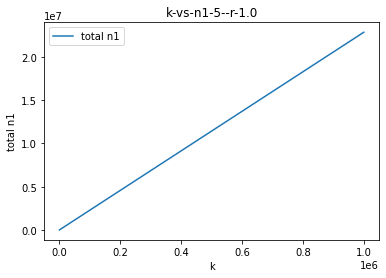

In [214]:
_fig, ax = plt.subplots(1,1)
for _val in VALENCIES:
    for _t in LERPS:
        ax.clear()
        plot_data = res[_val][_t]
        bins = list(k for k,p in plot_data.items())
        d_base_n1 = list(p['root_tile_n1'] for k,p in plot_data.items())
        d_total_n1 = list(p['total'] for k,p in plot_data.items())
        # bins = list(range(1001))
        ax.plot(bins, list(i for i in d_total_n1), label=f"total n1")
        # ax.semilogy(bins, d_total_n1, label=f"total n1")
        ax.legend()
        plt.title(f"k-vs-n1-{_val}--r-{_t}")
        plt.xlabel('k')
        plt.ylabel('total n1')
        plt.savefig(f"k-vs-n1-{_val}--r-{_t}.pdf")
        print(f"saved? k-vs-n1-{_val}--r-{_t}.pdf")
        # series
        # plt.hist

        # plt.legend()
        # plt.clear()


In [311]:
def do_plot(xs: list[float] | list[int], yss: list[tuple[str, list[float]]], title: str, xlab: str, ylab: str, ylog=False, xlog=False):
    _fig, ax = plt.subplots(1,1)
    plot_f = ax.semilogy if ylog and not xlog else ax.semilogx if xlog and not ylog else ax.loglog if xlog and ylog else ax.plot
    for ys in yss:
        plot_f(xs, ys[1], label=ys[0])
    ax.legend()
    plt.title(title)
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.savefig(f"{title}.pdf")
    print(f"saved? {title}.pdf")

In [345]:
def frange(start, stop, step):
    d = stop - start
    steps = ceil(d / step)
    return (i * step + start for i in range(steps))

In [336]:
def n_chains_per_layer(d: int, v=3, r=0.5, k=3000, bf=1/15, bh=84):
    assert 0 <= r <= 1
    n_tiles = 1
    simplex_n1 = k / 2 / bf / bh
    root_n1: float = ceil(simplex_n1 / 4)
    layer_tile_n1 = root_n1
    sigma_n1 = root_n1
    hist = [root_n1]
    s_hist = [root_n1]
    layer_n1 = layer_tile_n1
    for i in range(1, d+1):
        layer_tile_n1 *= r
        layer_tile_n1 = floor(layer_tile_n1)
        # if layer_tile_n1 < 1:
        #     layer_tile_n1 = 0
        hist.append(floor(layer_tile_n1))
        n_tiles = tiles_at_d(i, v=v)
        layer_n1 = floor(n_tiles * layer_tile_n1)
        sigma_n1 += layer_n1
        s_hist.append(floor(layer_n1))
        if layer_tile_n1 == 0:
            break
    return dict(layer_tile_n1=layer_tile_n1, n_tiles=n_tiles, layer_n1=layer_n1, sigma_n1=sigma_n1, hist=hist, 
                s_hist=s_hist, r=r, k=k, simplex_n1=simplex_n1, root_n1=root_n1,
                factor_more_chains=(sigma_n1 / simplex_n1)
                )

In [337]:
n_chains_per_layer(12, r=0.7, k=3000)

{'layer_tile_n1': 0,
 'n_tiles': 1536,
 'layer_n1': 0,
 'sigma_n1': 4477,
 'hist': [67, 46, 32, 22, 15, 10, 7, 4, 2, 1, 0],
 's_hist': [67, 138, 192, 264, 360, 480, 672, 768, 768, 768, 0],
 'r': 0.7,
 'k': 3000,
 'simplex_n1': 267.85714285714283,
 'root_n1': 67,
 'factor_more_chains': 16.714133333333336}

saved? chains in tiling vs k.pdf


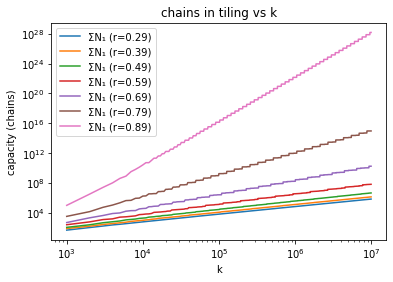

In [347]:
xs = list(k * 1000 for k in range(1, 10001))
ys: dict[str, list[float] | list[int]] = defaultdict(list)
for r in frange(0.29, 0.891, 0.1):
    label = f"ΣN₁ (r={r:.2f})"
    for k in xs:
        res = n_chains_per_layer(999, r=r, k=k)
        ys[label].append((res['sigma_n1']))
        # ys[label].append((res['sigma_n1'])/k)

yss = list((k,v) for k,v in ys.items())
do_plot(xs, yss, 'chains in tiling vs k', 'k', 'capacity (chains)', ylog=True, xlog=True)

saved? xFactor vs r.pdf


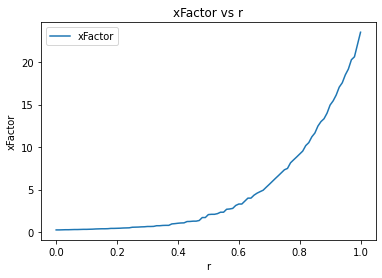

In [351]:
# x axis = r (ratio)
xs = list(frange(0, 1.001, 0.01))
ys: dict[str, list[float] | list[int]] = defaultdict(list)
for r in xs:
    # label = f"ΣN₁ (r={r:.1f})"
    res = n_chains_per_layer(5, r=r, k=3000)
    label = f"xFactor"
    ys[label].append(res['factor_more_chains'])
yss = list((k,v) for k,v in ys.items())
do_plot(xs, yss, 'xFactor vs r', 'r', 'xFactor')

saved? ΣN₁ vs r.pdf


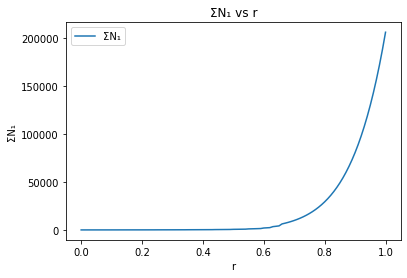

In [282]:
# x axis = r (ratio)
xs = list(frange(0, 1.001, 0.01))
ys: dict[str, list[float] | list[int]] = defaultdict(list)
for r in xs:
    # label = f"ΣN₁ (r={r:.1f})"
    res = n_chains_per_layer(10, r=r, k=3000)
    label = f"ΣN₁"
    ys[label].append(res['sigma_n1'])
yss = list((k,v) for k,v in ys.items())
do_plot(xs, yss, 'ΣN₁ vs r', 'r', 'ΣN₁',)

In [ ]:
# x axis = r (ratio)
xs = list(frange(0, 1.001, 0.01))
ys: dict[str, list[float] | list[int]] = defaultdict(list)
for r in xs:
    # label = f"ΣN₁ (r={r:.1f})"
    res = n_chains_per_layer(10, r=r, k=3000)
    label = f"ΣN₁"
    ys[label].append(res['sigma_n1'])
yss = list((k,v) for k,v in ys.items())
do_plot(xs, yss, 'ΣN₁ vs r', 'r', 'ΣN₁',)